# EDA - Battery Cycle Life Dataset
Exploratory Data Analysis untuk dataset LFP/graphite dari Severson et al. (2019)

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='darkgrid')
%matplotlib inline

In [2]:
DATA_DIR = '../../dataset'

BATCH_FILES = [
    '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    '2017-06-30_batchdata_updated_struct_errorcorrect.mat',
    '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
]

batch_paths = [os.path.join(DATA_DIR, f) for f in BATCH_FILES]

## 1. Load Cycle Life Semua Batch

In [3]:
def load_cycle_lives(path):
    f = h5py.File(path, 'r')
    batch = f['batch']
    n_cells = batch['cycle_life'].shape[0]
    cycle_lives = []
    for i in range(n_cells):
        ref = batch['cycle_life'][i][0]
        val = f[ref][0][0]
        cycle_lives.append(val)
    f.close()
    return cycle_lives

all_cycle_lives = []
batch_labels = []

for i, path in enumerate(batch_paths):
    lives = load_cycle_lives(path)
    all_cycle_lives.extend(lives)
    batch_labels.extend([f'batch_{i+1}'] * len(lives))
    print(f'Batch {i+1}: {len(lives)} sel')

print(f'\nTotal sel: {len(all_cycle_lives)}')

Batch 1: 46 sel
Batch 2: 48 sel
Batch 3: 46 sel

Total sel: 140


## 2. Statistik Dasar Cycle Life

In [4]:
df_life = pd.DataFrame({
    'cycle_life': all_cycle_lives,
    'batch': batch_labels
})

print(df_life['cycle_life'].describe())
print('\nPer batch:')
print(df_life.groupby('batch')['cycle_life'].describe())

count     138.000000
mean      791.507246
std       322.267632
min       148.000000
25%       499.750000
50%       787.000000
75%       987.250000
max      1935.000000
Name: cycle_life, dtype: float64

Per batch:
         count         mean         std    min     25%     50%      75%  \
batch                                                                     
batch_1   46.0   844.717391  184.629198  534.0  703.25   858.5   914.25   
batch_2   48.0   494.708333  141.111388  148.0  461.00   483.0   503.75   
batch_3   44.0  1059.659091  313.869692  541.0  828.00  1005.5  1155.25   

            max  
batch            
batch_1  1227.0  
batch_2  1061.0  
batch_3  1935.0  


## 3. Distribusi Cycle Life

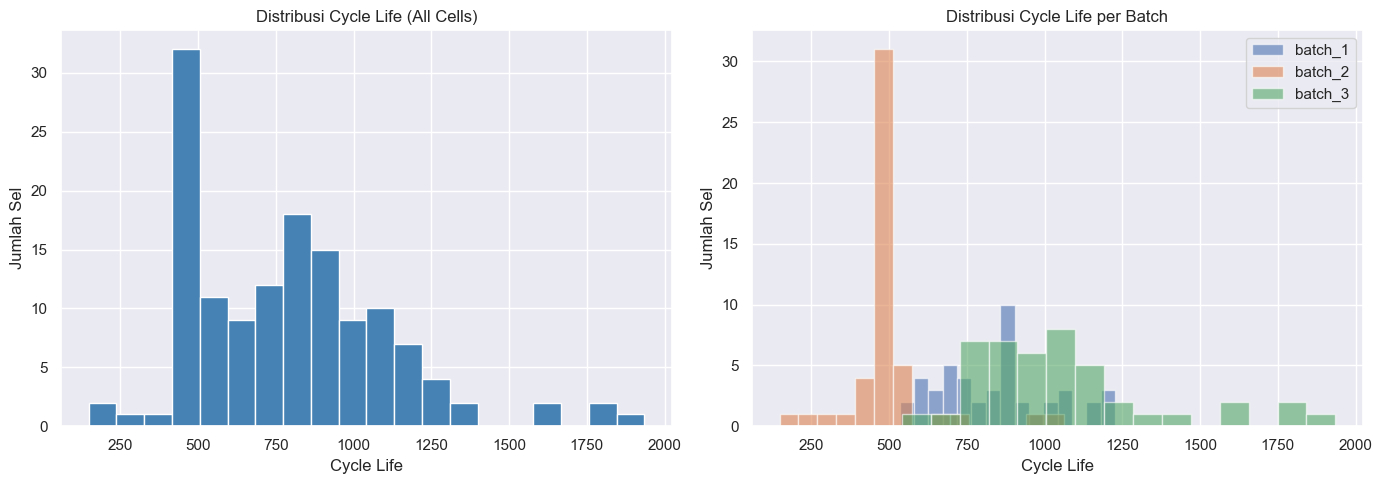

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_cycle_lives, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Cycle Life (All Cells)')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('Jumlah Sel')

for label in df_life['batch'].unique():
    subset = df_life[df_life['batch'] == label]['cycle_life']
    axes[1].hist(subset, bins=15, alpha=0.6, label=label, edgecolor='white')
axes[1].set_title('Distribusi Cycle Life per Batch')
axes[1].set_xlabel('Cycle Life')
axes[1].set_ylabel('Jumlah Sel')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Load Summary Data (QDischarge, IR, Tavg)

In [6]:
def load_summary(path):
    f = h5py.File(path, 'r')
    batch = f['batch']
    n_cells = batch['cycle_life'].shape[0]
    records = []
    for i in range(n_cells):
        cycle_life = f[batch['cycle_life'][i][0]][0][0]
        summary = f[batch['summary'][i][0]]
        QDischarge = summary['QDischarge'][0]
        IR = summary['IR'][0]
        Tavg = summary['Tavg'][0]
        records.append({
            'cell_id': i,
            'cycle_life': cycle_life,
            'QDischarge': QDischarge,
            'IR': IR,
            'Tavg': Tavg,
        })
    f.close()
    return records

all_summaries = []
for i, path in enumerate(batch_paths):
    records = load_summary(path)
    for r in records:
        r['batch'] = f'batch_{i+1}'
    all_summaries.extend(records)
    print(f'Batch {i+1}: {len(records)} sel loaded')

Batch 1: 46 sel loaded
Batch 2: 48 sel loaded
Batch 3: 46 sel loaded


## 5. Capacity Degradation Curve (QDischarge vs Cycle)

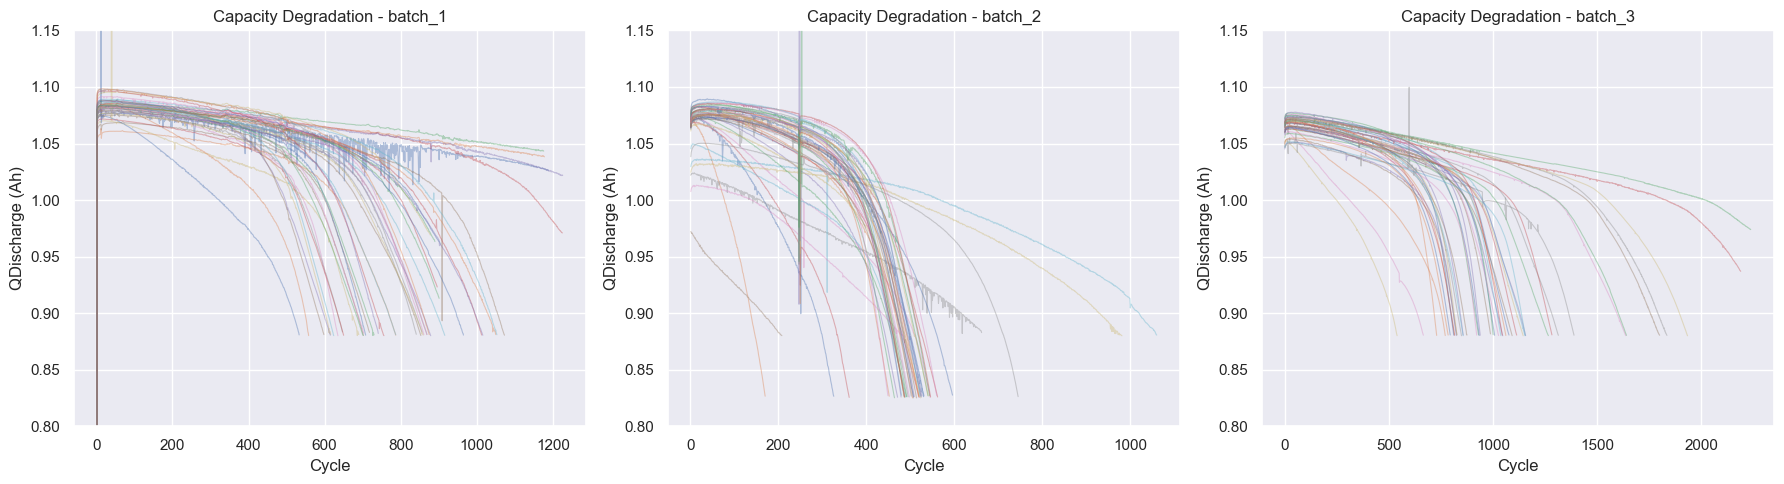

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, batch_name in zip(axes, ['batch_1', 'batch_2', 'batch_3']):
    subset = [s for s in all_summaries if s['batch'] == batch_name]
    for cell in subset:
        q = cell['QDischarge']
        cycles = np.arange(1, len(q) + 1)
        ax.plot(cycles, q, alpha=0.4, linewidth=0.8)
    ax.set_title(f'Capacity Degradation - {batch_name}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('QDischarge (Ah)')
    ax.set_ylim([0.8, 1.15])

plt.tight_layout()
plt.show()

## 6. Internal Resistance vs Cycle

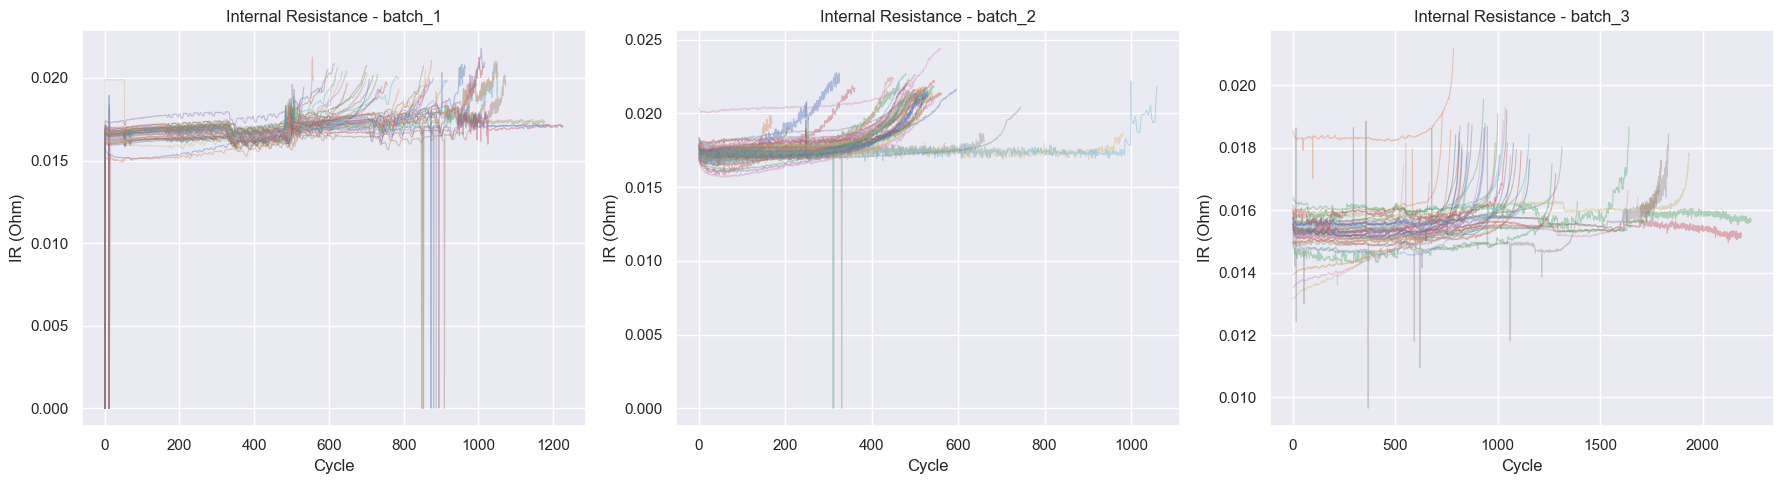

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, batch_name in zip(axes, ['batch_1', 'batch_2', 'batch_3']):
    subset = [s for s in all_summaries if s['batch'] == batch_name]
    for cell in subset:
        ir = cell['IR']
        cycles = np.arange(1, len(ir) + 1)
        ax.plot(cycles, ir, alpha=0.4, linewidth=0.8)
    ax.set_title(f'Internal Resistance - {batch_name}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('IR (Ohm)')

plt.tight_layout()
plt.show()

## 7. Korelasi Cycle Life vs Fitur Awal

In [9]:
features = []
for cell in all_summaries:
    q = cell['QDischarge']
    ir = cell['IR']
    if len(q) < 100:
        continue
    features.append({
        'cycle_life': cell['cycle_life'],
        'Q_mean_first100': np.mean(q[1:101]),
        'Q_min_first100': np.min(q[1:101]),
        'Q_var_first100': np.var(q[1:101]),
        'delta_Q_100_10': q[99] - q[9],
        'IR_mean_first100': np.mean(ir[1:101]),
        'batch': cell['batch'],
    })

df_feat = pd.DataFrame(features)
print(df_feat.shape)
df_feat.head()

(140, 7)


,cycle_life,Q_mean_first100,Q_min_first100,Q_var_first100,delta_Q_100_10,IR_mean_first100,batch
0,1190.0,1.080549,1.070689,0.002125,0.001375,0.016643,batch_1
1,1179.0,1.081241,1.075301,0.000001,0.000853,0.016753,batch_1
2,1177.0,1.085367,1.079922,0.000001,0.001159,0.016602,batch_1
3,1226.0,1.084946,1.079723,0.000001,0.000442,0.016149,batch_1
4,1227.0,1.082841,1.078018,0.000001,0.000692,0.016503,batch_1


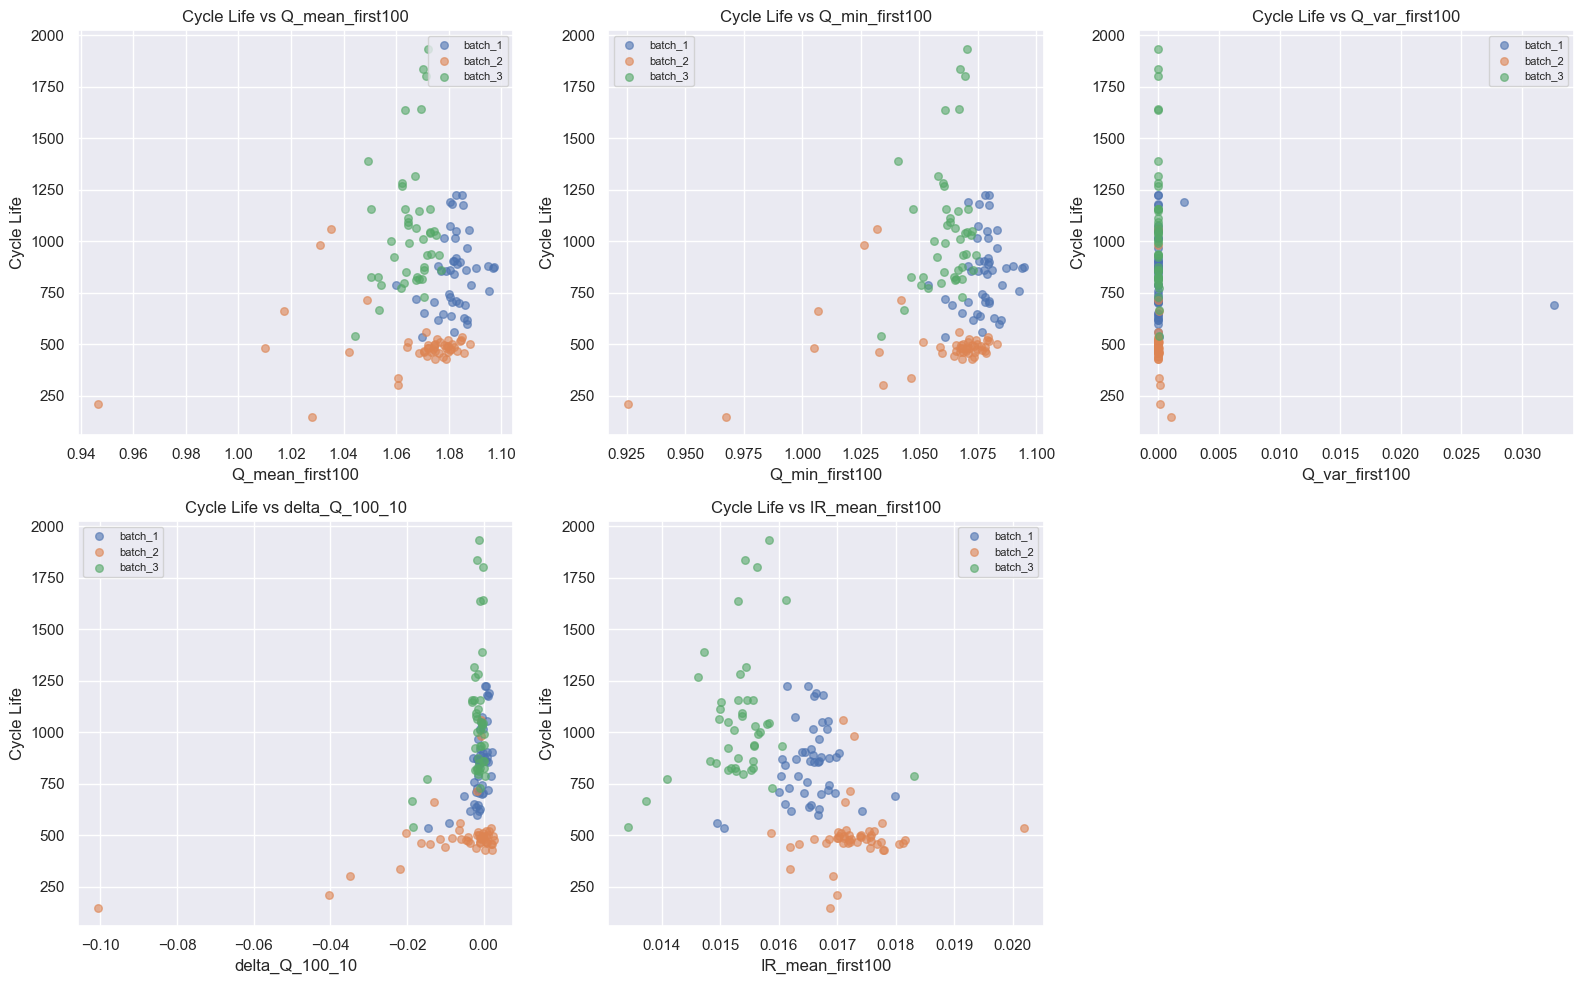

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

feat_cols = ['Q_mean_first100', 'Q_min_first100', 'Q_var_first100',
             'delta_Q_100_10', 'IR_mean_first100']

for ax, col in zip(axes, feat_cols):
    for batch in df_feat['batch'].unique():
        sub = df_feat[df_feat['batch'] == batch]
        ax.scatter(sub[col], sub['cycle_life'], alpha=0.6, label=batch, s=30)
    ax.set_xlabel(col)
    ax.set_ylabel('Cycle Life')
    ax.set_title(f'Cycle Life vs {col}')
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 8. Correlation Matrix

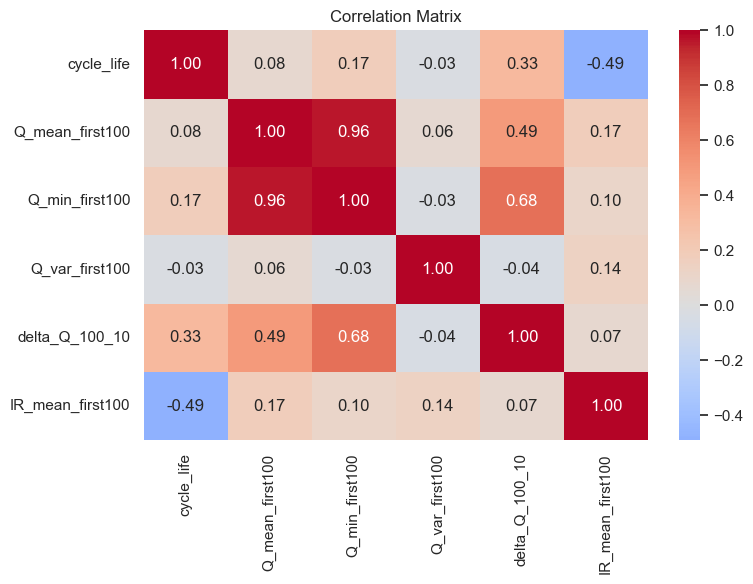

In [11]:
corr = df_feat[['cycle_life'] + feat_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 9. Cek Missing / Anomali

Missing values:
cycle_life          2
Q_mean_first100     0
Q_min_first100      0
Q_var_first100      0
delta_Q_100_10      0
IR_mean_first100    0
batch               0
dtype: int64

Sel dengan cycle_life < 200: 1
Sel dengan cycle_life > 2000: 0


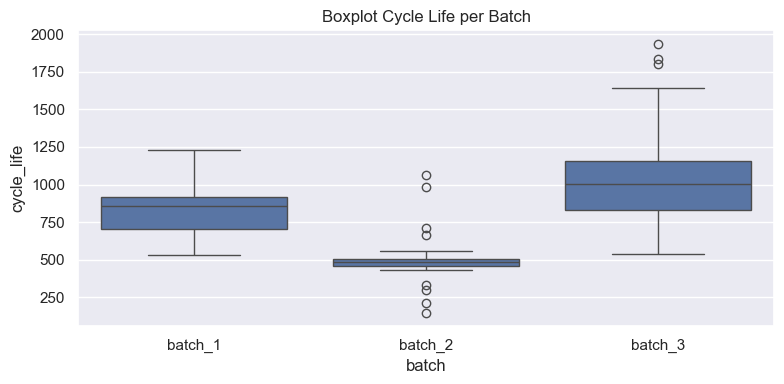

In [12]:
print('Missing values:')
print(df_feat.isnull().sum())

print(f'\nSel dengan cycle_life < 200: {(df_feat["cycle_life"] < 200).sum()}')
print(f'Sel dengan cycle_life > 2000: {(df_feat["cycle_life"] > 2000).sum()}')

plt.figure(figsize=(8, 4))
sns.boxplot(x='batch', y='cycle_life', data=df_feat)
plt.title('Boxplot Cycle Life per Batch')
plt.tight_layout()
plt.show()

## 10. Sample Discharge Voltage Curve (Cycles Data)

Jumlah cycles sel 0: 1189


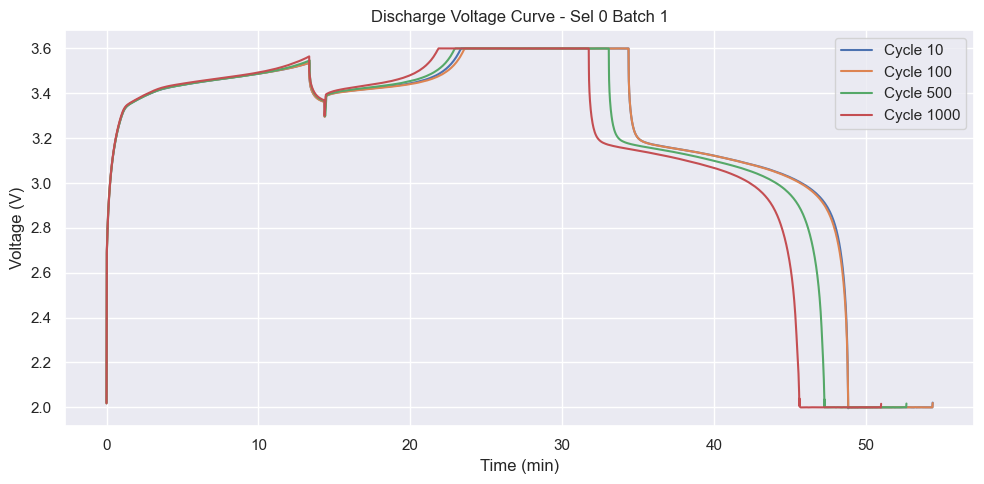

In [13]:
f = h5py.File(batch_paths[0], 'r')
batch = f['batch']

cell0_cycles = f[batch['cycles'][0][0]]
n_cycles = cell0_cycles['V'].shape[0]
print(f'Jumlah cycles sel 0: {n_cycles}')

sample_cycles = [10, 100, 500, 1000]
plt.figure(figsize=(10, 5))

for c in sample_cycles:
    if c >= n_cycles:
        continue
    v_ref = cell0_cycles['V'][c][0]
    t_ref = cell0_cycles['t'][c][0]
    V = f[v_ref][:].flatten()
    t = f[t_ref][:].flatten()
    plt.plot(t, V, label=f'Cycle {c}')

plt.title('Discharge Voltage Curve - Sel 0 Batch 1')
plt.xlabel('Time (min)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.tight_layout()
plt.show()
f.close()